<a href="https://colab.research.google.com/github/kailashscse2025-alt/DAA/blob/main/DAA8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


       TRAVELLING SALESMAN PROBLEM

5-City Cost Matrix:

               A       B       C       D       E
------------------------------------------------
       A     INF      10       8       9       7
       B      10     INF      10       5       6
       C       8      10     INF       8       9
       D       9       5       8     INF       6
       E       7       6       9       6     INF


             OPTIMAL TOUR
Optimal Tour : A -> E -> B -> D -> C -> A
Minimum Cost : 34


             PATH VERIFICATION
From      To        Cost      
------------------------------
A         E         7         
E         B         6         
B         D         5         
D         C         8         
C         A         8         
------------------------------
Total               34


             BRUTE FORCE VERIFICATION
Branch and Bound Cost : 34
Brute Force Cost      : 34

✓ Result Verified Successfully!


/tmp/ipykernel_3568/4056202516.py:410: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_3568/4056202516.py:467: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


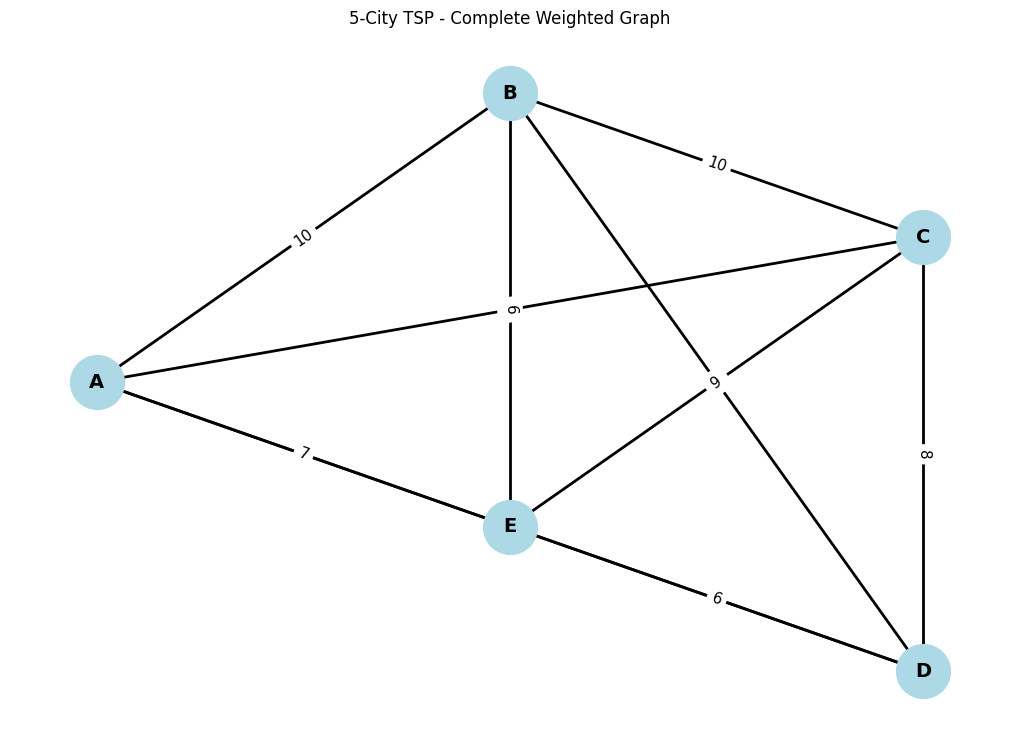

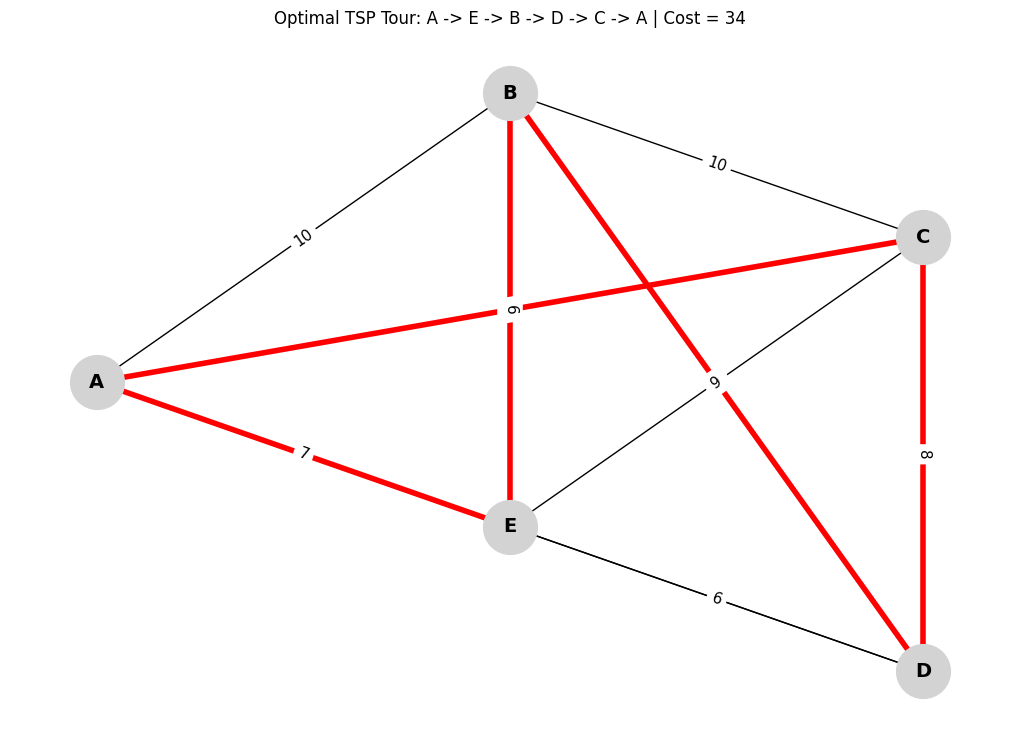

In [1]:
import heapq
import matplotlib.pyplot as plt
import networkx as nx

INF = float('inf')


# ==========================================
# MATRIX REDUCTION
# ==========================================

def reduce_matrix(mat):
    """
    Reduce matrix and return:
    reduced matrix + reduction cost
    """

    m = [row[:] for row in mat]
    n = len(m)
    reduction_cost = 0

    # Row reduction
    for i in range(n):

        row_min = min(m[i])

        if row_min != INF and row_min != 0:

            reduction_cost += row_min

            for j in range(n):

                if m[i][j] != INF:
                    m[i][j] -= row_min

    # Column reduction
    for j in range(n):

        col_min = min(
            m[i][j]
            for i in range(n)
        )

        if col_min != INF and col_min != 0:

            reduction_cost += col_min

            for i in range(n):

                if m[i][j] != INF:
                    m[i][j] -= col_min

    return m, reduction_cost


# ==========================================
# TSP BRANCH AND BOUND
# ==========================================

def tsp_branch_and_bound(cost, n):

    best_cost = INF
    best_path = None

    # Initial lower bound
    reduced_matrix, initial_cost = reduce_matrix(cost)

    # Priority queue:
    # (lower_bound, current_cost, current_city, path, matrix)
    pq = []

    heapq.heappush(
        pq,
        (
            initial_cost,
            0,
            0,
            [0],
            reduced_matrix
        )
    )

    while pq:

        bound, current_cost, current_city, path, matrix = heapq.heappop(pq)

        # Prune
        if bound >= best_cost:
            continue

        # All cities visited
        if len(path) == n:

            final_cost = current_cost + cost[current_city][0]

            if final_cost < best_cost:

                best_cost = final_cost
                best_path = path + [0]

            continue

        # Try all unvisited cities
        for next_city in range(n):

            if next_city in path:
                continue

            if cost[current_city][next_city] == INF:
                continue

            new_matrix = [
                row[:]
                for row in matrix
            ]

            # Set current row to INF
            for j in range(n):
                new_matrix[current_city][j] = INF

            # Set current column to INF
            for i in range(n):
                new_matrix[i][next_city] = INF

            # Prevent returning to starting city early
            new_matrix[next_city][0] = INF

            # Reduce new matrix
            reduced_matrix, reduction_cost = reduce_matrix(new_matrix)

            new_current_cost = (
                current_cost
                + cost[current_city][next_city]
            )

            new_bound = (
                new_current_cost
                + reduction_cost
            )

            if new_bound < best_cost:

                heapq.heappush(
                    pq,
                    (
                        new_bound,
                        new_current_cost,
                        next_city,
                        path + [next_city],
                        reduced_matrix
                    )
                )

    return best_path, best_cost


# ==========================================
# BRUTE FORCE FOR VERIFICATION
# ==========================================

from itertools import permutations


def tsp_brute_force(cost, n):

    cities = list(range(1, n))

    best_cost = INF
    best_path = None

    for perm in permutations(cities):

        path = [0] + list(perm) + [0]

        total = 0

        for i in range(n):
            total += cost[path[i]][path[i + 1]]

        if total < best_cost:

            best_cost = total
            best_path = path

    return best_path, best_cost


# ==========================================
# COST MATRIX
# ==========================================

cost = [
    [INF, 10, 8, 9, 7],
    [10, INF, 10, 5, 6],
    [8, 10, INF, 8, 9],
    [9, 5, 8, INF, 6],
    [7, 6, 9, 6, INF]
]

n = 5

cities = ['A', 'B', 'C', 'D', 'E']


# ==========================================
# RUN BRANCH AND BOUND
# ==========================================

best_path, best_cost = tsp_branch_and_bound(
    cost,
    n
)


# ==========================================
# BRUTE FORCE VERIFICATION
# ==========================================

verify_path, verify_cost = tsp_brute_force(
    cost,
    n
)


# ==========================================
# COST MATRIX TABLE
# ==========================================

print("\n================================================")
print("       TRAVELLING SALESMAN PROBLEM")
print("================================================")

print("\n5-City Cost Matrix:\n")

print(
    f"{'':>8}"
    + "".join(f"{c:>8}" for c in cities)
)

print("-" * 48)

for i, row in enumerate(cost):

    print(
        f"{cities[i]:>8}",
        end=""
    )

    for value in row:

        if value == INF:
            value = "INF"

        print(
            f"{str(value):>8}",
            end=""
        )

    print()


# ==========================================
# OPTIMAL TOUR TABLE
# ==========================================

print("\n\n================================================")
print("             OPTIMAL TOUR")
print("================================================")

tour_string = " -> ".join(
    cities[i]
    for i in best_path
)

print("Optimal Tour :", tour_string)
print("Minimum Cost :", best_cost)


# ==========================================
# PATH VERIFICATION TABLE
# ==========================================

print("\n\n================================================")
print("             PATH VERIFICATION")
print("================================================")

print(
    f"{'From':<10}"
    f"{'To':<10}"
    f"{'Cost':<10}"
)

print("-" * 30)

total = 0

for i in range(n):

    u = best_path[i]
    v = best_path[i + 1]

    edge_cost = cost[u][v]

    total += edge_cost

    print(
        f"{cities[u]:<10}"
        f"{cities[v]:<10}"
        f"{edge_cost:<10}"
    )

print("-" * 30)

print(
    f"{'Total':<20}{total}"
)


# ==========================================
# VERIFICATION RESULT
# ==========================================

print("\n\n================================================")
print("             BRUTE FORCE VERIFICATION")
print("================================================")

print(
    "Branch and Bound Cost :",
    best_cost
)

print(
    "Brute Force Cost      :",
    verify_cost
)

if best_cost == verify_cost:
    print("\n✓ Result Verified Successfully!")


# ==========================================
# GRAPH
# ==========================================

G = nx.Graph()

# Add nodes
for city in cities:
    G.add_node(city)


# Add edges
for i in range(n):

    for j in range(i + 1, n):

        if cost[i][j] != INF:

            G.add_edge(
                cities[i],
                cities[j],
                weight=cost[i][j]
            )


# Fixed positions for a clean graph
pos = {
    'A': (0, 2),
    'B': (2, 4),
    'C': (4, 3),
    'D': (4, 0),
    'E': (2, 1)
}


# ==========================================
# ORIGINAL GRAPH
# ==========================================

plt.figure(figsize=(10, 7))

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=1500,
    node_color="lightblue",
    font_size=14,
    font_weight="bold",
    width=2
)

edge_labels = nx.get_edge_attributes(
    G,
    'weight'
)

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=11
)

plt.title(
    "5-City TSP - Complete Weighted Graph"
)

plt.axis("off")
plt.tight_layout()


# ==========================================
# OPTIMAL TOUR GRAPH
# ==========================================

plt.figure(figsize=(10, 7))

# Draw all edges lightly
nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=1500,
    node_color="lightgray",
    font_size=14,
    font_weight="bold",
    width=1
)

# Create optimal tour graph
tour_graph = nx.Graph()

for i in range(n):

    u = cities[best_path[i]]
    v = cities[best_path[i + 1]]

    tour_graph.add_edge(
        u,
        v,
        weight=cost[best_path[i]][best_path[i + 1]]
    )


# Highlight optimal tour
nx.draw_networkx_edges(
    tour_graph,
    pos,
    edge_color="red",
    width=4
)

# Show weights
nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=11
)

plt.title(
    f"Optimal TSP Tour: {tour_string} | Cost = {best_cost}"
)

plt.axis("off")
plt.tight_layout()

plt.show()